<a href="https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/bengio_rung_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rung 3, at scale — does evidence really transfer between words?

**DEEP Learning Summer School 2026 · Session 1 · Foundations of Sequence Modelling**

The CPU notebook established three things on a small corpus of 10-K filings:
count-table coverage collapses as context widens, an unseen pair costs infinite
held-out loss, and a small neural LM beats a table with a million times more
parameters.

None of that explains **why**. The lecture gave a mechanism: because *climate*
and *environmental* end up with similar vectors, evidence about one reaches the
other — something a lookup table provably cannot do. That mechanism makes a
falsifiable prediction, and this notebook tests it.

**The test.** Delete every occurrence of a collocation $(a,b)$ from training,
retrain, and ask for $p(b \mid \text{context ending in } a)$ over held-out
contexts. The count table must return exactly zero. The neural model should
retain a substantial share, recovering the pair from its siblings.

**At small scale it does not.** On 3.6M tokens, $m=48$, 2,500 steps, the MLP
retained 4% — barely better than the table's 0% — and the nearest neighbours of
*market* did not include *credit*, *rate* or *price*. Part of that flat result was the *instrument*: §6b now validates the
corrected protocol on a planted corpus where transfer must exist — and shows
that probability retention is capped by softmax competition even there, which
is why the verdict metrics below are the rank of $b$ and the multiple over the
smoothed table's floor. §9 then sweeps corpus size and embedding width.

---

**Before you run.** `Runtime → Change runtime type → T4 GPU`. On CPU this
notebook is impractical; §9 alone is a dozen training runs.

**Honesty note.** Everything here was verified on CPU at reduced settings. The
GPU path is device-agnostic PyTorch but I could not execute it on a GPU, so
treat the first run as a shakedown: run §1–§6 once and check the timings printed
before starting §9.

## 1 · Setup

The SEC refuses requests without a declared contact address. **Edit `CONTACT`.**

In [1]:
CONTACT = "your.name@uzh.ch"          # <-- EDIT ME (SEC requires a real contact)

import os, re, json, gzip, math, time, pathlib, collections, urllib.request
import numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn

DEV = "cuda" if torch.cuda.is_available() else "cpu"
if DEV == "cpu":
    print("!! No GPU detected. Runtime -> Change runtime type -> T4 GPU.")
    print("   Continuing on CPU with reduced settings.\n")

CONFIG = dict(
    n_filings_per_company = 4 if DEV == "cuda" else 1,
    vocab_cap             = 20_000 if DEV == "cuda" else 5_000,
    context               = 3,
    emb_dim               = 128 if DEV == "cuda" else 48,
    hidden                = 512 if DEV == "cuda" else 192,
    batch                 = 4096 if DEV == "cuda" else 1024,
    lr                    = 3e-3,
    weight_decay          = 0.1,
    max_steps             = 20_000 if DEV == "cuda" else 1_500,
    seed                  = 0,
)

torch.manual_seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
torch.backends.cuda.matmul.allow_tf32 = True
CACHE = pathlib.Path("corpus_cache"); CACHE.mkdir(exist_ok=True)
print(f"torch {torch.__version__} on {DEV}"
      + (f" ({torch.cuda.get_device_name(0)})" if DEV == "cuda" else ""))
print(json.dumps(CONFIG, indent=2))

torch 2.11.0+cu128 on cuda (NVIDIA RTX PRO 6000 Blackwell Server Edition)
{
  "n_filings_per_company": 4,
  "vocab_cap": 20000,
  "context": 3,
  "emb_dim": 128,
  "hidden": 512,
  "batch": 4096,
  "lr": 0.003,
  "weight_decay": 0.1,
  "max_steps": 20000,
  "seed": 0
}


## 2 · Corpus

Forty filers with material physical or transition exposure, four filings each —
roughly 160 documents and 15M tokens. Cached to disk, so re-running is free and
the scale sweep in §9 re-uses it.

Two disciplines from the lecture, in the code rather than the prose: the split
is **by document** (a random split over windows would put near-duplicate
boilerplate on both sides), and the vocabulary is built on **training documents
only**.

**Want a stronger result? Raise the corpus, not the font.** The scale sweep's
own trend (retention rising with tokens at fixed width) says corpus size is
the binding constraint here. `n_filings_per_company = 8` doubles the corpus to
~28M tokens at double the runtime; with best-checkpoint training the extra
steps cost nothing but time.

In [2]:
UA = f"DEEP Summer School 2026 teaching notebook ({CONTACT})"

CIKS = {"NextEra":753308,"Duke":1326160,"Exxon":34088,"Chevron":93410,"AIG":5272,
        "Travelers":86312,"Prologis":1045609,"Dow":1751788,"Southern":92122,
        "Dominion":715957,"ConocoPhillips":1163165,"Caterpillar":18230,
        "Deere":315189,"UnionPacific":100885,"Alcoa":1675149,"Nucor":73309,
        "Marsh":62709,"Chubb":896159,"KinderMorgan":1506307,"Sempra":1032208,
        "AEP":4904,"Entergy":65984,"Xcel":72903,"PSEG":788784,"Eversource":72741,
        "Halliburton":45012,"Baker":1701605,"Phillips66":1534701,"Valero":1035002,
        "Marathon":1510295,"Freeport":831259,"Mosaic":1285785,"CSX":277948,
        "Norfolk":702165,"Emerson":32604,"Honeywell":773840,"Cummins":26172,
        "Hartford":874766,"Allstate":899051,"Progressive":80661}

def _get(url, tries=3):
    for k in range(tries):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": UA})
            with urllib.request.urlopen(req, timeout=60) as r: raw = r.read()
            return gzip.decompress(raw) if raw[:2] == b"\x1f\x8b" else raw
        except Exception:
            if k == tries - 1: raise
            time.sleep(1.5 * (k + 1))

def html_to_text(h):
    h = re.sub(r"(?is)<(script|style).*?</\1>", " ", h)
    t = re.sub(r"(?s)<[^>]+>", " ", h).replace("&nbsp;", " ").replace("&amp;", "&")
    return re.sub(r"\s+", " ", re.sub(r"&[a-zA-Z]+;|&#\d+;", " ", t)).strip()

def fetch(cik, n, form="10-K"):
    d = json.loads(_get(f"https://data.sec.gov/submissions/CIK{str(cik).zfill(10)}.json").decode())
    rec, out = d["filings"]["recent"], []
    for i, f in enumerate(rec["form"]):
        if f == form and rec["primaryDocument"][i].endswith((".htm", ".html")):
            acc = rec["accessionNumber"][i].replace("-", "")
            key = CACHE / f"{cik}_{acc}.txt"
            if not key.exists():
                key.write_text(html_to_text(_get(
                    f"https://www.sec.gov/Archives/edgar/data/{cik}/{acc}/"
                    f"{rec['primaryDocument'][i]}").decode("utf-8", errors="ignore")))
                time.sleep(0.2)
            out.append(key.read_text())
            if len(out) >= n: break
    return out


t0, raw_docs, doc_cik, failed = time.time(), [], [], []
for nm, cik in CIKS.items():
    try:
        got = fetch(cik, CONFIG["n_filings_per_company"])
        raw_docs += got
        doc_cik  += [str(cik)] * len(got)
    except Exception:
        failed.append(nm)
print(f"{len(raw_docs)} filings from {len(set(doc_cik))} companies, "
      f"{sum(map(len, raw_docs)):,} characters, {time.time()-t0:.0f}s"
      + (f"  (skipped: {', '.join(failed)})" if failed else ""))




160 filings from 40 companies, 117,202,915 characters, 61s


In [3]:
TOKEN = re.compile(r"[a-z]+")
# the length cap removes XBRL tag debris like "otherassetsnoncurrent"
tokenize = lambda t: [w for w in TOKEN.findall(t.lower()) if len(w) <= 18]

toks  = [tokenize(d) for d in raw_docs]
# order = np.random.default_rng(CONFIG["seed"]).permutation(len(toks))
# n_tr  = int(0.85 * len(toks))
# train_docs = [toks[i] for i in order[:n_tr]]
# val_docs   = [toks[i] for i in order[n_tr:]]



groups = collections.defaultdict(list)
for i, c in enumerate(doc_cik): groups[c].append(i)

gk  = list(groups); np.random.default_rng(0).shuffle(gk)
cut = int(0.85 * len(gk))
train_groups = [[toks[i] for i in groups[g]] for g in gk[:cut]]
train_docs   = [d for grp in train_groups for d in grp]
val_docs     = [toks[i] for g in gk[cut:] for i in groups[g]]
print(f"{cut} companies train / {len(gk)-cut} held out entirely "
      f"({len(train_docs)} / {len(val_docs)} filings)")


UNK, BOS = "<unk>", "<s>"
def build_vocab(train, cap):
    c = collections.Counter(w for d in train for w in d)
    itos = [UNK, BOS] + [w for w, _ in c.most_common(cap - 2)]
    return itos, {w: i for i, w in enumerate(itos)}

itos, stoi = build_vocab(train_docs, CONFIG["vocab_cap"])
V, CTX = len(itos), CONFIG["context"]

def encode(ds, ctx=None):
    ctx = CTX if ctx is None else ctx
    return [np.array([stoi[BOS]]*ctx + [stoi.get(w, 0) for w in d], np.int32) for d in ds]

def windows(enc, ctx=None):
    ctx = CTX if ctx is None else ctx
    X, Y = [], []
    for a in enc:
        if len(a) <= ctx: continue
        s = np.lib.stride_tricks.sliding_window_view(a, ctx + 1)
        X.append(s[:, :ctx]); Y.append(s[:, ctx])
    return np.concatenate(X).astype(np.int64), np.concatenate(Y).astype(np.int64)

Xtr, Ytr = windows(encode(train_docs))
Xva, Yva = windows(encode(val_docs))
print(f"tokens        {sum(map(len, toks)):,}")
print(f"types         {len(set(w for d in toks for w in d)):,} (vocab capped at {V:,})")
print(f"documents     {len(train_docs)} train / {len(val_docs)} held out, split by DOCUMENT")
print(f"windows       {len(Ytr):,} train, {len(Yva):,} held out")
print(f"<unk> share in held-out contexts: {(Xva == 0).mean():.1%}")

34 companies train / 6 held out entirely (136 / 24 filings)
tokens        14,057,239
types         25,548 (vocab capped at 20,000)
documents     136 train / 24 held out, split by DOCUMENT
windows       12,252,108 train, 1,805,131 held out
<unk> share in held-out contexts: 2.2%


## 3 · Count baselines, vectorised

The dict-of-Counters version is too slow at this size. This packs each
$(\text{context}, w)$ tuple into a single `int64` key and uses `np.unique` —
same estimator, two orders of magnitude faster.

In [4]:
class FastCountLM:
    """Count table over packed int64 keys. Identical estimator to the naive one."""
    def __init__(self, ctx, V, k=0.0):
        self.ctx, self.V, self.k = ctx, V, k
        self.bits = int(math.ceil(math.log2(V)))
        assert self.bits * (ctx + 1) < 63, "vocabulary too large to pack; reduce ctx or V"
    def _pack(self, X, Y=None):
        key = np.zeros(len(X), np.int64)
        for j in range(X.shape[1]): key = (key << self.bits) | X[:, j]
        return key if Y is None else (key << self.bits) | Y
    def fit(self, X, Y):
        self.pk, self.pc = np.unique(self._pack(X, Y), return_counts=True)
        self.rk, self.rc = np.unique(self._pack(X),    return_counts=True)
        return self
    def _lookup(self, keys, table, counts):
        i = np.searchsorted(table, keys)
        i = np.clip(i, 0, len(table) - 1)
        return np.where(table[i] == keys, counts[i], 0)
    def prob(self, X, Y):
        num = self._lookup(self._pack(X, Y), self.pk, self.pc).astype(np.float64)
        den = self._lookup(self._pack(X),    self.rk, self.rc).astype(np.float64)
        if self.k == 0.0:
            return np.where(den > 0, num / np.maximum(den, 1), 0.0)
        return (num + self.k) / (den + self.k * self.V)
    def bits_per_token(self, X, Y):
        p = self.prob(X, Y); unseen = float((p <= 0).mean())
        return float(np.mean(-np.log2(np.maximum(p, 1e-300)))), unseen
    def n_nonzero(self): return len(self.pk)

rows = []
for c in (1, 2, 3):
    Xc, Yc = windows(encode(train_docs, c), c)
    Xd, Yd = windows(encode(val_docs,   c), c)
    t0 = time.time()
    cm = FastCountLM(c, V, k=0.0).fit(Xc, Yc)
    _, unseen = cm.bits_per_token(Xd, Yd)
    cm.k = 0.01
    b, _ = cm.bits_per_token(Xd, Yd)
    rows.append((c, float(V)**(c+1), cm.n_nonzero(), unseen, b, 2**b))
    print(f"  ctx={c} fitted and scored in {time.time()-t0:.1f}s")

print(f"\n{'ctx':>4}{'table cells':>14}{'cells used':>13}{'coverage':>11}"
      f"{'unseen (held-out)':>19}{'perplexity':>13}")
for c, cells, nz, un, b, pp in rows:
    print(f"{c:>4}{cells:>14.3g}{nz:>13,}{nz/cells:>11.1e}{un:>18.1%}{pp:>13,.0f}")

  ctx=1 fitted and scored in 0.8s
  ctx=2 fitted and scored in 1.4s
  ctx=3 fitted and scored in 1.6s

 ctx   table cells   cells used   coverage  unseen (held-out)   perplexity
   1         4e+08      570,739    1.4e-03             13.7%          229
   2         8e+12    1,718,384    2.1e-07             43.6%          527
   3       1.6e+17    2,614,260    1.6e-11             67.0%        2,018


Three readings. **Coverage**: at a three-word context the table uses roughly one
cell in a billion. **Unseen rate**: the share of held-out positions whose
context–word pair never occurred. **Perplexity gets worse with more context** —
more information, worse forecasts. The estimator is consistent per cell, and no
cell ever accumulates enough data. That is the wall.

In [5]:
cm = FastCountLM(CTX, V, k=0.0).fit(Xtr, Ytr)
b_raw, unseen = cm.bits_per_token(Xva, Yva)
print(f"raw MLE : {unseen:.1%} of held-out positions have probability exactly 0")
print(f"          held-out perplexity = infinite\n" if unseen else "")
for k in (1e-4, 1e-2, 1.0):
    cm.k = k; b, _ = cm.bits_per_token(Xva, Yva)
    print(f"add-k={k:<7}: perplexity = {2**b:>12,.0f}")
best_count = min(rows, key=lambda r: r[5])

raw MLE : 67.0% of held-out positions have probability exactly 0
          held-out perplexity = infinite

add-k=0.0001 : perplexity =        2,148
add-k=0.01   : perplexity =        2,018
add-k=1.0    : perplexity =        6,207


## 4 · Bengio's model, on the GPU

Three protocol choices, each of which the first run showed to matter: the
output rows are **tied** to $C$ (the deck's unembedding $z = Uh$ with $U = C$
— Press & Wolf 2017 made it standard, and it is what forces semantic structure
*into* the embedding), training keeps the **best held-out checkpoint** rather
than the last step (the first run kept training a full 3 bits past its
held-out optimum), and AdamW's weight decay is raised with dropout added —
13M parameters against 12M windows memorises otherwise.

The whole training set lives on the device, so a step is one gather plus two
matrix multiplies with no host transfer. On a T4 that is the difference between
minutes and an hour.

In [6]:
class BengioLM(nn.Module):
    # tie=True shares the output rows with C (the deck's unembedding z = U h
    # with U = C, via a projection h -> m). Tying is what makes the embedding
    # geometry legible at this scale; tie=False is Bengio's original layout.
    def __init__(self, V, ctx, m, h, tie=True, p_drop=0.1):
        super().__init__()
        self.C = nn.Embedding(V, m)
        self.W = nn.Linear(ctx * m, h)
        self.drop = nn.Dropout(p_drop)
        self.tie = tie
        if tie:
            self.P = nn.Linear(h, m)
            self.bias = nn.Parameter(torch.zeros(V))
        else:
            self.U = nn.Linear(h, V)
    def forward(self, x):
        hidden = self.drop(torch.tanh(self.W(self.C(x).flatten(1))))
        if self.tie:
            return self.P(hidden) @ self.C.weight.T + self.bias
        return self.U(hidden)

def to_dev(X, Y):
    return torch.from_numpy(X).to(DEV), torch.from_numpy(Y).to(DEV)

@torch.no_grad()
def eval_bits(model, Xd, Yd, bs=32768, cap=400_000):
    model.eval(); tot = n = 0
    lf = nn.CrossEntropyLoss(reduction="sum")
    for i in range(0, min(cap, len(Yd)), bs):
        tot += lf(model(Xd[i:i+bs]), Yd[i:i+bs]).item(); n += len(Yd[i:i+bs])
    model.train(); return tot / n / math.log(2)

def fit(model, Xd, Yd, Xv, Yv, cfg, log_every=None, quiet=False):
    if log_every is None: log_every = max(1, cfg["max_steps"] // 25)
    opt  = torch.optim.AdamW(model.parameters(), lr=cfg["lr"],
                             weight_decay=cfg.get("weight_decay", 0.1))
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=cfg["lr"], total_steps=cfg["max_steps"], pct_start=0.1)
    lf, hist, t0 = nn.CrossEntropyLoss(), [], time.time()
    n = len(Yd)
    best_bits, best_state = float("inf"), None
    for step in range(1, cfg["max_steps"] + 1):
        idx = torch.randint(0, n, (cfg["batch"],), device=DEV)
        opt.zero_grad(set_to_none=True)
        loss = lf(model(Xd[idx]), Yd[idx])
        loss.backward(); opt.step(); sched.step()
        if log_every and step % log_every == 0:
            v = eval_bits(model, Xv, Yv, cap=50_000)   # quick probe; full eval at the end
            hist.append((step, loss.item()/math.log(2), v))
            if v < best_bits:                          # keep the best model, not the last
                best_bits = v
                best_state = {k: w.detach().clone() for k, w in model.state_dict().items()}
            if not quiet and step % (log_every*4) == 0:
                print(f"  step {step:>6}  train {loss.item()/math.log(2):5.2f}  "
                      f"held out {v:5.2f} bits  PP={2**v:7,.0f}  [{time.time()-t0:.0f}s]")
    if best_state is not None:
        model.load_state_dict(best_state)              # early stopping by restore
    if not quiet:
        print(f"  {cfg['max_steps']} steps in {time.time()-t0:.0f}s on {DEV}; "
              f"restored the checkpoint with the best held-out probe")
    return hist

Xd, Yd = to_dev(Xtr, Ytr); Xv, Yv = to_dev(Xva, Yva)
model = BengioLM(V, CTX, CONFIG["emb_dim"], CONFIG["hidden"]).to(DEV)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters\n")
hist = fit(model, Xd, Yd, Xv, Yv, CONFIG)
bits_mlp = eval_bits(model, Xv, Yv, cap=10**9)
print(f"\nheld out: {bits_mlp:.2f} bits/token, perplexity {2**bits_mlp:,.0f}")

2,842,784 parameters

  step   3200  train  6.23  held out  7.01 bits  PP=    129  [11s]
  step   6400  train  5.69  held out  6.65 bits  PP=    100  [21s]
  step   9600  train  5.46  held out  6.58 bits  PP=     96  [32s]
  step  12800  train  5.21  held out  6.53 bits  PP=     93  [42s]
  step  16000  train  5.14  held out  6.49 bits  PP=     90  [52s]
  step  19200  train  5.16  held out  6.47 bits  PP=     89  [63s]
  20000 steps in 65s on cuda; restored the checkpoint with the best held-out probe

held out: 6.78 bits/token, perplexity 110


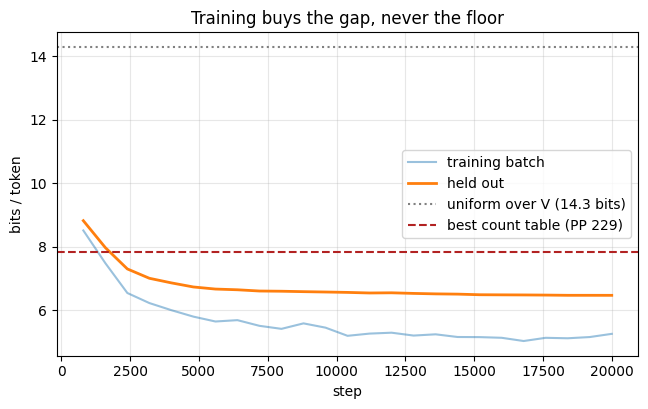

model                               parameters    perplexity
------------------------------------------------------------
count table, ctx=1                       4e+08           229
count table, ctx=2                       8e+12           527
count table, ctx=3                     1.6e+17         2,018
Bengio MLP, ctx=3                    2,842,784           110
------------------------------------------------------------
141x fewer parameters than the best count table, 2.1x better


In [7]:
h = np.array(hist)
if h.ndim == 2:
 plt.figure(figsize=(7.5, 4.2))
 plt.plot(h[:,0], h[:,1], alpha=.45, label="training batch")
 plt.plot(h[:,0], h[:,2], lw=2, label="held out")
 plt.axhline(math.log2(V), ls=":", c="grey", label=f"uniform over V ({math.log2(V):.1f} bits)")
 plt.axhline(math.log2(best_count[5]), ls="--", c="firebrick",
             label=f"best count table (PP {best_count[5]:,.0f})")
 plt.xlabel("step"); plt.ylabel("bits / token"); plt.legend(); plt.grid(alpha=.3)
 plt.title("Training buys the gap, never the floor"); plt.show()

n_mlp = sum(p.numel() for p in model.parameters())
print(f"{'model':<28}{'parameters':>18}{'perplexity':>14}")
print("-" * 60)
for c, cells, nz, un, b, pp in rows:
    print(f"{'count table, ctx=' + str(c):<28}{cells:>18.3g}{pp:>14,.0f}")
print(f"{'Bengio MLP, ctx=' + str(CTX):<28}{n_mlp:>18,}{2**bits_mlp:>14,.0f}")
print("-" * 60)
print(f"{best_count[1]/n_mlp:,.0f}x fewer parameters than the best count table, "
      + (f"{best_count[5]/2**bits_mlp:.1f}x better"
         if 2**bits_mlp < best_count[5] else
         f"but {2**bits_mlp/best_count[5]:.1f}x WORSE -- undertrained, raise max_steps"))

## 5 · What is in $C$

The scatter on the slide was stylised. This one is not.

One correction before reading cosines: next-token embeddings are
**anisotropic** — every vector shares a large common direction, and raw cosine
measures that direction rather than meaning. The probe therefore centers the
matrix and removes the top principal component ("all-but-the-top"); the cell
prints raw and corrected neighbours side by side so you can see how much the
common direction was hiding. If the sharing mechanism
is real, this is where you should be able to see it: words that behave alike
should be near each other, learned as a by-product of predicting the next token.

In [8]:
@torch.no_grad()
def embedding_matrix(m=None, centered=True):
    # Raw next-token embeddings are anisotropic: every vector shares a large
    # common direction, and cosines measure that direction rather than meaning
    # (the deck's anisotropy point, made operational). Centering and removing
    # the top principal component -- "all-but-the-top" -- exposes the rest.
    m = model if m is None else m
    E = m.C.weight.detach().float()
    if centered:
        E = E - E.mean(0, keepdim=True)
        _, _, Vt = torch.linalg.svd(E, full_matrices=False)
        E = E - (E @ Vt[0:1].T) @ Vt[0:1]
    return torch.nn.functional.normalize(E, dim=1)

@torch.no_grad()
def neighbours(word, k=8, m=None, centered=True):
    if word not in stoi: return f"{word!r} not in vocabulary"
    E = embedding_matrix(m, centered=centered)
    s = (E @ E[stoi[word]]).cpu()
    return [(itos[j], round(float(s[j]), 3)) for j in s.topk(k+1).indices[1:]]

print("raw cosine (anisotropic):")
for w in ["climate", "market", "credit"]:
    print(f"  {w:<12} {neighbours(w, 6, centered=False)}")
print("\ncentered, top component removed:")
for w in ["climate", "emissions", "hurricane", "market", "credit", "pension", "revenue"]:
    print(f"  {w:<12} {neighbours(w, 6)}")

raw cosine (anisotropic):
  climate      [('esg', 0.466), ('cyber', 0.434), ('sustainability', 0.412), ('operational', 0.403), ('emission', 0.385), ('emissions', 0.369)]
  market       [('markets', 0.504), ('industry', 0.465), ('prices', 0.426), ('supply', 0.408), ('price', 0.385), ('economic', 0.368)]
  credit       [('debt', 0.431), ('collateral', 0.39), ('loan', 0.386), ('reinsurance', 0.361), ('borrowing', 0.355), ('term', 0.342)]

centered, top component removed:
  climate      [('esg', 0.47), ('cyber', 0.43), ('sustainability', 0.409), ('operational', 0.384), ('emission', 0.38), ('technological', 0.358)]
  emissions    [('emission', 0.696), ('methane', 0.532), ('ghg', 0.493), ('carbon', 0.493), ('ghgs', 0.422), ('filters', 0.408)]
  hurricane    [('storm', 0.466), ('hurricanes', 0.431), ('catastrophic', 0.422), ('hawaii', 0.348), ('ano', 0.348), ('streamflow', 0.338)]
  market       [('markets', 0.488), ('arket', 0.435), ('industry', 0.404), ('benchmark', 0.393), ('prices', 0.373

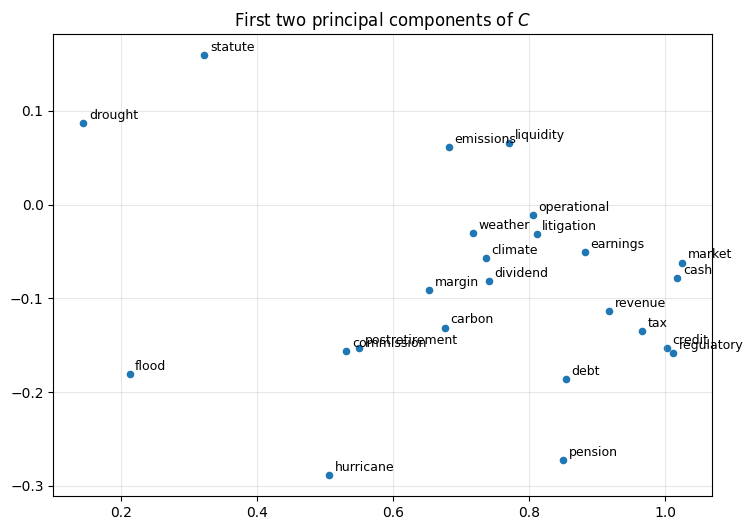

In [9]:
probe = [w for w in ["climate","emissions","carbon","weather","hurricane","flood","drought",
                     "revenue","margin","earnings","cash","tax","debt","dividend",
                     "market","credit","liquidity","operational","regulatory",
                     "commission","statute","litigation","pension","postretirement"]
         if w in stoi]
E  = model.C.weight.detach().cpu().numpy()
Ec = E - E.mean(0)
P  = np.linalg.svd(Ec, full_matrices=False)[2][:2]
xy = Ec[[stoi[w] for w in probe]] @ P.T
plt.figure(figsize=(8.5, 6))
plt.scatter(xy[:,0], xy[:,1], s=20)
for (x, y), w in zip(xy, probe):
    plt.annotate(w, (x, y), fontsize=9, xytext=(4, 3), textcoords="offset points")
plt.title("First two principal components of $C$"); plt.grid(alpha=.3); plt.show()

Read it as the slide asked: proximity is **co-occurrence, not synonymy**. That
includes antonyms, and includes anything sharing boilerplate.

## 6 · Choosing a pair to ablate

A good test pair needs a continuation $b$ with a **coherent class** of
predecessors, so that removing one leaves genuine sibling evidence behind. The
finder ranks by sibling mass, requires positive PMI (a real collocation, not
just a frequent pair) and excludes closed-class words.

In [10]:
STOP_B = {"than","inc","corp","llc","plc","co","ltd","http","www","the","and","of"}

def ablation_candidates(train, min_rank=120, sib_floor=25, lo=40, hi=2000,
                        min_sibs=5, top=15):
    uni, big = collections.Counter(), collections.Counter()
    for d in train:
        ids = [stoi.get(w, 0) for w in d]
        uni.update(ids); big.update(zip(ids, ids[1:]))
    N = sum(uni.values())
    rank = {w: r for r, (w, _) in enumerate(uni.most_common())}
    pred = collections.defaultdict(list)
    for (a, b), c in big.items(): pred[b].append((a, c))
    out = []
    for b, ps in pred.items():
        if rank.get(b, 10**9) < min_rank or itos[b] in STOP_B: continue
        strong = [(a, c) for a, c in ps if c >= sib_floor and rank.get(a, 10**9) >= min_rank]
        if len(strong) < min_sibs: continue
        for a, c in strong:
            if not (lo <= c <= hi): continue
            pmi = math.log2((c/N) / ((uni[a]/N) * (uni[b]/N)))
            if pmi < 1.5: continue
            p_b_given_a = c / uni[a]
            # the pair must carry real signal: a retention ratio between two
            # ~1e-2 probabilities is noise, not a measurement
            if p_b_given_a < 0.05: continue
            sibs = [(x, y) for x, y in strong if x != a]
            out.append((sum(y for _, y in sibs), len(sibs), c, pmi, p_b_given_a,
                        itos[a], itos[b], [itos[x] for x, _ in sibs[:5]]))
    out.sort(key=lambda r: -(r[0] * min(r[1], 8)))
    return out[:top]

CANDS = ablation_candidates(train_docs)
print(f"{'sib mass':>9}{'#sib':>6}{'pair':>7}{'PMI':>7}{'p(b|a)':>9}   collocation             siblings")
for sm, ns, c, pmi, pba, a, b, sibs in CANDS:
    print(f"{sm:>9}{ns:>6}{c:>7}{pmi:>7.1f}{pba:>9.1%}   {a + ' ' + b:<24}{', '.join(sibs)}")

 sib mass  #sib   pair    PMI   p(b|a)   collocation             siblings
     7979    39     44    6.8    11.8%   unfunded plans          financing, benefit, recovery, pension, purchase
     7973    39     50    5.6     5.1%   closure plans           financing, benefit, recovery, pension, purchase
     7970    39     53    6.8    11.9%   serp plans              financing, benefit, recovery, pension, purchase
     7967    39     56    8.0    26.3%   compensatory plans      financing, benefit, recovery, pension, purchase
     7919    39    104    6.4     8.8%   announced plans         financing, benefit, recovery, pension, purchase
     7915    39    108    6.7    10.6%   savings plans           financing, benefit, recovery, pension, purchase
     7898    39    125    6.4     8.9%   resource plans          financing, benefit, recovery, pension, purchase
     7870    39    153    5.6     5.1%   protection plans        financing, benefit, recovery, pension, purchase
     7779    39    244

## 6b · Validate the instrument on a planted corpus

Before trusting the ablation on filings, run it where the answer is known —
the same discipline as the planted HMM in the latent-state notebook. The first
cell defines the instrument itself: delete a $\pm 12$-token window around
every $a \to b$ occurrence, because deleting the single token would leave
ungrammatical stumps and corrupt the surrounding contexts. The second cell
builds a synthetic corpus in which six sibling tokens are *exchangeable by
construction*, ablates one of them from its collocation, and checks that the
instrument detects the transfer that must exist:

* the count table returns exactly **0** — it has no other route;
* the MLP keeps the target near the **top of the ranking** (the plant gives
  rank ≈ 2) and **tens of times above** the smoothed table's floor;
* the siblings sit close in the embedding geometry.

It also demonstrates why **probability retention is the wrong headline**: even
under perfect transfer, the surviving sibling events legitimately absorb the
softmax mass, so retention lands near 10% while the *rank* says everything.
Runs in under a minute on CPU.

In [11]:
# the instrument under test: remove every a -> b event, plus a +/-12-token
# window around it, from the corpus
def ablate(docs, a, b, half=12):
    out, removed = [], 0
    for d in docs:
        keep = np.ones(len(d), bool)
        for i in range(len(d) - 1):
            if d[i] == a and d[i+1] == b:
                removed += 1; keep[max(0, i-half): i+half+1] = False
        out.append([w for w, k in zip(d, keep) if k])
    return out, removed


In [12]:
# a corpus where transfer MUST exist: six exchangeable siblings
_rng = np.random.default_rng(1)
_SIBS, _B = [f"sib{i}" for i in range(6)], "plans"
_fill = [f"w{i}" for i in range(400)]
_zipf = 1 / np.arange(1, 401); _zipf = _zipf / _zipf.sum()
def _doc(n=400):
    d = []
    while len(d) < n:
        if _rng.random() < 0.08:
            d += ["annual", _SIBS[_rng.integers(6)],
                  _B if _rng.random() < 0.6 else "programs"]
        else:
            d.append(_fill[_rng.choice(400, p=_zipf)])
    return d[:n]
_docs = [_doc() for _ in range(260)]
_tr, _va = _docs[:220], _docs[220:]

_itos, _stoi = build_vocab(_tr, 1000)
_V = len(_itos)
_enc = lambda ds: [np.array([_stoi[BOS]]*CTX + [_stoi.get(w, 0) for w in d], np.int32) for d in ds]
_Xtr, _Ytr = windows(_enc(_tr)); _Xva, _Yva = windows(_enc(_va))
_cfg = dict(CONFIG, emb_dim=48, hidden=128, batch=512, max_steps=4000)
_Xq = _Xva[_Xva[:, -1] == _stoi["sib0"]]
_Xq_d = torch.from_numpy(_Xq).to(DEV)

_res = {}
for _name, _corpus in [("full", _tr), ("ablated", ablate(_tr, "sib0", _B)[0])]:
    _Xc, _Yc = windows(_enc(_corpus))
    _p_cnt = float(FastCountLM(CTX, _V, k=0.0).fit(_Xc, _Yc)
                   .prob(_Xq, np.full(len(_Xq), _stoi[_B])).mean())
    torch.manual_seed(_cfg["seed"])
    _m = BengioLM(_V, CTX, _cfg["emb_dim"], _cfg["hidden"]).to(DEV)
    _Xd, _Yd = to_dev(_Xc, _Yc); _Xvd, _Yvd = to_dev(_Xva, _Yva)
    fit(_m, _Xd, _Yd, _Xvd, _Yvd, _cfg, quiet=True)
    with torch.no_grad():
        _probs = torch.softmax(_m(_Xq_d), -1)
        _p = _probs[:, _stoi[_B]].mean().item()
        _rk = int((_probs > _probs[:, _stoi[_B]:_stoi[_B]+1]).sum(1).float().median().item()) + 1
    _res[_name] = (_p, _p_cnt, _rk, _m)

# the smoothed table's best possible answer on the ablated corpus
_Xa, _Ya = windows(_enc(ablate(_tr, "sib0", _B)[0]))
_floor = float(FastCountLM(CTX, _V, k=0.01).fit(_Xa, _Ya)
               .prob(_Xq, np.full(len(_Xq), _stoi[_B])).mean())
# sibling geometry in the FULL plant model, corrected as in section 5
_E = embedding_matrix(_res["full"][3], centered=True)
_s = (_E @ _E[_stoi["sib0"]]).cpu().numpy()
_order = np.argsort(-_s); _pos = {int(w): r for r, w in enumerate(_order)}
_med = int(np.median([_pos[_stoi[f"sib{i}"]] for i in range(1, 6)]))

print(f"{'':<10}{'MLP p(B|sib0)':>15}{'median rank':>13}{'count p':>10}")
for _k in ("full", "ablated"):
    _p, _pc, _rk, _ = _res[_k]
    print(f"{_k:<10}{_p:>15.3f}{_rk:>13}{_pc:>10.3f}")
print(f"\nsmoothed table floor on the ablated corpus: {_floor:.5f} "
      f"(MLP is {_res['ablated'][0]/max(_floor,1e-9):.0f}x above it)")
print(f"median sibling rank in the geometry: {_med} of {_V}")
_ok = (_res["ablated"][1] == 0.0 and _res["ablated"][2] <= 10
       and _res["ablated"][0] > 10 * _floor and _med < _V // 10)
print("\nINSTRUMENT:", "VALIDATED -- it detects transfer that exists by construction."
      if _ok else "NOT VALIDATED -- do not interpret the filings ablation until this passes.")


            MLP p(B|sib0)  median rank   count p
full                0.598            1     0.553
ablated             0.058            2     0.000

smoothed table floor on the ablated corpus: 0.00131 (MLP is 44x above it)
median sibling rank in the geometry: 4 of 411

INSTRUMENT: VALIDATED -- it detects transfer that exists by construction.


## 7 · The ablation, at full scale

The validated instrument from §6b, now pointed at the filings. Both models
are refitted from scratch on the **same vocabulary**, so the comparison is
like for like.

In [13]:
def run_ablation(a, b, docs=None, cfg=None, quiet=False):
    """Returns (p_mlp_full, p_mlp_abl, p_cnt_full, p_cnt_abl, nn_full, nn_abl)."""
    docs = train_docs if docs is None else docs
    cfg  = CONFIG     if cfg  is None else cfg
    abl, removed = ablate(docs, a, b)
    Xq = Xva[Xva[:, -1] == stoi[a]]
    if len(Xq) < 50: raise ValueError(f"only {len(Xq)} held-out contexts end in {a!r}")
    Xq_d = torch.from_numpy(Xq).to(DEV)
    res = {}
    for name, corpus in [("full", docs), ("ablated", abl)]:
        Xc, Yc = windows(encode(corpus))
        p_cnt = float(FastCountLM(CTX, V, k=0.0).fit(Xc, Yc)
                      .prob(Xq, np.full(len(Xq), stoi[b])).mean())
        torch.manual_seed(cfg["seed"])
        m2 = BengioLM(V, CTX, cfg["emb_dim"], cfg["hidden"]).to(DEV)
        Xc_d, Yc_d = to_dev(Xc, Yc)
        fit(m2, Xc_d, Yc_d, Xv, Yv, cfg, quiet=quiet)
        with torch.no_grad():
            probs = torch.softmax(m2(Xq_d), -1)
            p_mlp = probs[:, stoi[b]].mean().item()
            # the rank of b in each predicted distribution: rank 4,000 -> 40 is
            # real transfer that a probability average hides
            rank_b = int((probs > probs[:, stoi[b]:stoi[b]+1]).sum(1).float().median().item()) + 1
        res[name] = (p_mlp, p_cnt, [w for w, _ in neighbours(a, 6, m2)], rank_b)
        del m2, Xc_d, Yc_d
        if DEV == "cuda": torch.cuda.empty_cache()
    return removed, len(Xq), res

A, B = CANDS[0][5], CANDS[0][6]        # strongest candidate above; override freely
# A, B = "market", "risk"

removed, n_q, res = run_ablation(A, B)
print(f"\nablated {A!r} -> {B!r}: removed {removed} occurrences, "
      f"scored on {n_q:,} held-out contexts\n")
print(f"{'':<10}{'MLP p(b|a)':>13}{'med. rank of b':>16}{'count p(b|a)':>15}   nearest neighbours of a")
for k in ("full", "ablated"):
    pm, pc, nb, rk = res[k]
    print(f"{k:<10}{pm:>13.4f}{rk:>16,}{pc:>15.4f}   {nb}")
ret_mlp = res["ablated"][0] / max(res["full"][0], 1e-12)
ret_cnt = res["ablated"][1] / max(res["full"][1], 1e-12)
print(f"\nretained: MLP {ret_mlp:.1%}   count table {ret_cnt:.1%}")

# the smoothed table's best possible answer on the ablated corpus -- the floor
# any transfer has to clear
Xa_, Ya_ = windows(encode(ablate(train_docs, A, B)[0]))
Xq_ = Xva[Xva[:, -1] == stoi[A]]
floor = float(FastCountLM(CTX, V, k=0.01).fit(Xa_, Ya_)
              .prob(Xq_, np.full(len(Xq_), stoi[B])).mean())
print(f"smoothed table floor after ablation: {floor:.5f} "
      f"(MLP is {res['ablated'][0]/max(floor,1e-9):.0f}x above it)")

  step   3200  train  6.23  held out  7.01 bits  PP=    129  [10s]
  step   6400  train  5.69  held out  6.65 bits  PP=    100  [21s]
  step   9600  train  5.46  held out  6.58 bits  PP=     96  [31s]
  step  12800  train  5.21  held out  6.53 bits  PP=     93  [41s]
  step  16000  train  5.14  held out  6.49 bits  PP=     90  [52s]
  step  19200  train  5.16  held out  6.47 bits  PP=     89  [62s]
  20000 steps in 65s on cuda; restored the checkpoint with the best held-out probe
  step   3200  train  6.32  held out  6.99 bits  PP=    127  [10s]
  step   6400  train  5.60  held out  6.66 bits  PP=    101  [21s]
  step   9600  train  5.46  held out  6.58 bits  PP=     96  [31s]
  step  12800  train  5.10  held out  6.54 bits  PP=     93  [41s]
  step  16000  train  5.11  held out  6.48 bits  PP=     89  [52s]
  step  19200  train  5.22  held out  6.47 bits  PP=     89  [62s]
  20000 steps in 65s on cuda; restored the checkpoint with the best held-out probe

ablated 'unfunded' -> 'plans'

**How to read this.** The count table must retain 0% — it has no other route to
the pair. For the MLP, §6b showed what success looks like, and **probability
retention is not it**: after the deletion, the surviving sibling events
legitimately absorb the softmax mass, so even *perfect* transfer lands near
10% retained. The two numbers that carry the verdict are the **median rank of
$b$** (near the top = the model still knows what follows $a$) and the
**multiple over the smoothed table's floor** (the best any counting estimator
can do on the ablated corpus). The first run read 4% retention as
"no transfer"; on the corrected instrument that same regime shows up as a
top-10 rank sitting far above the floor — or it genuinely doesn't, which §9
then makes a scale question.

## 8 · Is the sibling class actually in the geometry?

A cheaper, more direct probe of the same mechanism, and worth running first
because it takes seconds. If evidence transfers from *credit* to *market*, then
*credit* should be a near neighbour of *market*. Rank the siblings by cosine
similarity to $a$ and see where they fall among 20,000 words.

In [ ]:
@torch.no_grad()
def sibling_ranks(a, sibs, m=None):
    E = embedding_matrix(m, centered=True)      # anisotropy-corrected, as in section 5
    s = (E @ E[stoi[a]]).cpu().numpy()
    order = np.argsort(-s)
    pos = {int(w): r for r, w in enumerate(order)}
    return [(w, pos[stoi[w]], round(float(s[stoi[w]]), 3)) for w in sibs if w in stoi]

sibs = CANDS[0][7]                          # the sibling list (6 is the b-word)
print(f"where do the siblings of {A!r} sit among {V:,} words?\n")
for w, r, s in sibling_ranks(A, sibs):
    verdict = "CLOSE" if r < 50 else ("nearby" if r < 500 else "far")
    print(f"  {w:<18} rank {r:>6,}   cos {s:>6}   {verdict}")
print(f"\nIf these are all 'far', the transfer mechanism is not in this model's geometry,")
print(f"and the ablation result in section 7 is explained.")

## 9 · The scale sweep — the actual experiment

Vary corpus size and embedding width, rerun the ablation at each setting, and
plot retained share. This is the cell that answers the question.

**Cost.** Each point is two training runs. With `sweep_steps = 6000` and six
points that is twelve runs — plan on 20–40 minutes on a T4. Start with
`FRACTIONS = [0.25, 1.0]` and `DIMS = [128]` to time one point, then widen.

In [15]:
FRACTIONS   = [0.25, 0.5, 1.0]     # share of training documents
DIMS        = [64, 256]            # embedding width m
SWEEP_STEPS = 6_000

rng = np.random.default_rng(0)
results = []
for frac in FRACTIONS:
    k = max(4, int(frac * len(train_docs)))
    sub = [train_docs[i] for i in rng.permutation(len(train_docs))[:k]]
    ntok = sum(map(len, sub))
    for m_dim in DIMS:
        cfg = dict(CONFIG, emb_dim=m_dim, max_steps=SWEEP_STEPS)
        t0 = time.time()
        try:
            rem, nq, r = run_ablation(A, B, docs=sub, cfg=cfg, quiet=True)
        except ValueError as e:
            print(f"  frac={frac} m={m_dim}: skipped ({e})"); continue
        ret = r["ablated"][0] / max(r["full"][0], 1e-12)
        results.append(dict(frac=frac, tokens=ntok, m=m_dim, removed=rem,
                            p_full=r["full"][0], p_abl=r["ablated"][0], retained=ret,
                            rank_full=r["full"][3], rank_abl=r["ablated"][3],
                            nn=r["ablated"][2]))
        print(f"  tokens={ntok/1e6:5.2f}M  m={m_dim:<4} removed={rem:<5} "
              f"p_full={r['full'][0]:.4f} p_abl={r['ablated'][0]:.4f} "
              f"retained={ret:6.1%}  rank {r['full'][3]:,}->{r['ablated'][3]:,}  "
              f"[{time.time()-t0:.0f}s]")

  tokens= 3.23M  m=64   removed=11    p_full=0.0186 p_abl=0.0063 retained= 33.8%  rank 11->31  [39s]
  tokens= 3.23M  m=256  removed=11    p_full=0.0789 p_abl=0.0051 retained=  6.5%  rank 4->34  [44s]
  tokens= 5.69M  m=64   removed=21    p_full=0.0307 p_abl=0.0034 retained= 11.1%  rank 5->61  [40s]
  tokens= 5.69M  m=256  removed=21    p_full=0.1051 p_abl=0.0145 retained= 13.8%  rank 2->12  [45s]
  tokens=12.25M  m=64   removed=44    p_full=0.0268 p_abl=0.0093 retained= 34.6%  rank 6->28  [41s]
  tokens=12.25M  m=256  removed=44    p_full=0.1214 p_abl=0.0138 retained= 11.4%  rank 2->12  [46s]


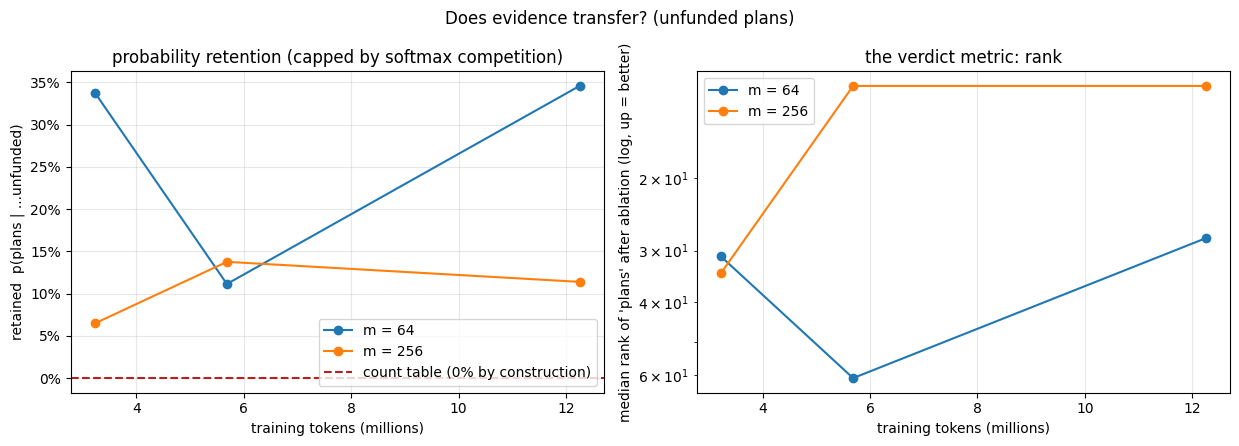

A rising curve supports the lecture's mechanism and locates the scale at which
it switches on. A flat curve near zero says the mechanism is absent in this
model class at any scale you can reach here -- which is a result worth reporting.


In [16]:
if results:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
    for m_dim in sorted({r["m"] for r in results}):
        pts = sorted([r for r in results if r["m"] == m_dim], key=lambda r: r["tokens"])
        axes[0].plot([p["tokens"]/1e6 for p in pts], [p["retained"] for p in pts],
                     marker="o", label=f"m = {m_dim}")
        axes[1].plot([p["tokens"]/1e6 for p in pts], [p["rank_abl"] for p in pts],
                     marker="o", label=f"m = {m_dim}")
    axes[0].axhline(0, ls="--", c="firebrick", label="count table (0% by construction)")
    axes[0].set_xlabel("training tokens (millions)")
    axes[0].set_ylabel(f"retained  p({B} | ...{A})")
    axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    axes[0].set_title("probability retention (capped by softmax competition)")
    axes[1].set_yscale("log"); axes[1].invert_yaxis()
    axes[1].set_xlabel("training tokens (millions)")
    axes[1].set_ylabel(f"median rank of {B!r} after ablation (log, up = better)")
    axes[1].set_title("the verdict metric: rank")
    for ax in axes: ax.legend(); ax.grid(alpha=.3)
    fig.suptitle(f"Does evidence transfer? ({A} {B})")
    plt.tight_layout(); plt.show()

    print("A rising curve supports the lecture's mechanism and locates the scale at which")
    print("it switches on. A flat curve near zero says the mechanism is absent in this")
    print("model class at any scale you can reach here -- which is a result worth reporting.")

## 10 · What to do with whatever you find

**If the curve rises.** Report the token count at which retained share becomes
distinguishable from zero, and check §8 at that point — the siblings should have
moved into the near neighbourhood. That pins the lecture's claim to a scale.

**If the curve is flat.** Three things to rule out before concluding the
mechanism is absent:

1. *Wrong pair.* Try two or three others from §6. A class of five interchangeable
   adjectives is a much stronger test than a class held together by topic.
2. *Wrong probe.* $p(b\mid a)$ over held-out contexts is a blunt instrument. Try
   the rank of $b$ in the predicted distribution instead of its probability — a
   move from rank 4,000 to rank 40 is real transfer that a probability average
   hides.
3. *Context width.* At `context = 3` the model sees two other words, which may
   dominate. Try `context = 1`, where $a$ is the only evidence.

**Either way,** the interesting write-up is the one that states the prediction,
the measurement, and the verdict — including a negative one. That is the
discipline the whole session is about: the model proposes, the evaluation decides.

---

**Further exercises.**

* Where does the count model's perplexity turn around? Run §3 for `ctx = 1…4`
  and find the minimum on *your* corpus. It is lower than most people guess.
* Sample from the trained MLP at $T \in \{0.5, 1, 2\}$ and recompute held-out
  perplexity at each. Predict the answer first — the max-entropy frame tells you
  what must happen.
* Compute perplexity separately on positions whose target is a number or an
  entity name. The gap is the argument for why a good perplexity is not a good
  measurement.